In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F

In [2]:
# Adjust only if this notebook is not under <project_root>/notebooks
import os 
project_path = Path.cwd().parent

if str(project_path / "src") not in sys.path:
    sys.path.insert(0, str(project_path / "src"))
os.chdir(project_path)
from credit_risk.utils.config import read_config, create_path
from credit_risk.modelling.artifacts_spark import load_spark_model_artifacts
from credit_risk.modelling.data_spark import load_modelling_vintage_spark

In [3]:
config = read_config(project_path)

parameters = config["parameters"]
modelling_config = parameters["modelling"]
features_config = modelling_config["features"]

print("Modelling approach :", parameters["modelling_approach"])
print("Engine             :", parameters["engine"])
print("Algorithm          :", modelling_config["algorithm"])
print("Model version      :", modelling_config["version"])

print("\nConfigured numerical features:")
print(features_config["numerical_features"])

print("\nConfigured categorical features:")
print(features_config["categorical_features"])

print("\nConfigured engineered features:")
print(features_config["engineered_features"])

Modelling approach : behavioral
Engine             : pyspark
Algorithm          : xgboost
Model version      : test_unbalanced_quarterly

Configured numerical features:
['number_of_borrowers', 'mi_percentage', 'original_upb', 'credit_score', 'original_dti', 'original_ltv', 'original_cltv', 'current_actual_upb', 'current_interest_rate', 'estimated_ltv', 'calculated_loan_age', 'remaining_months_to_legal_maturity', 'current_non_interest_bearing_upb', 'current_interest_bearing_upb', 'non_interest_bearing_upb_pct', 'interest_bearing_upb_pct', 'current_dpd_numeric', 'max_dpd_to_date', 'delinquency_months_to_date', 'months_since_last_delinquency', 'ever_30dpd_to_date', 'ever_60dpd_to_date', 'ever_modified', 'ever_payment_deferred', 'ever_borrower_assistance', 'ever_disaster_delinquency', 'dpd_30_count_6m', 'dpd_60_count_6m', 'max_dpd_6m', 'delinquency_months_6m', 'modification_count_6m', 'payment_deferral_count_6m', 'borrower_assistance_count_6m', 'disaster_delinquency_count_6m', 'rate_step_c

In [4]:
from credit_risk.utils.spark import create_spark_session

spark = create_spark_session(config)

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [5]:
model, preprocessor = load_spark_model_artifacts(config)

print("Model:")
print(model)

print("\nPreprocessor:")
print(preprocessor)

Model:
SparkXGBClassifier_5b23668040cc

Preprocessor:
PipelineModel_8f3738fd76e2


In [6]:
approach = parameters["modelling_approach"]

train_path = create_path(
    config["catalog"]["base"],
    config["catalog"],
    "train_df",
    approach,
    must_exist=True,
)

print("Training split:")
print(train_path)

train_df = spark.read.parquet(str(train_path))

print("Rows:", train_df.count())
print("Columns:", len(train_df.columns))

train_df.printSchema()

Training split:
data\04_model_split\behavioral\train_split.parquet
Rows: 10970334
Columns: 80
root
 |-- loan_id: string (nullable = true)
 |-- observation_age: integer (nullable = true)
 |-- period: long (nullable = true)
 |-- current_actual_upb: double (nullable = true)
 |-- current_interest_rate: double (nullable = true)
 |-- loan_age: long (nullable = true)
 |-- remaining_months_to_legal_maturity: long (nullable = true)
 |-- estimated_ltv: long (nullable = true)
 |-- current_loan_delinquency_status: string (nullable = true)
 |-- ddlpi: long (nullable = true)
 |-- modification_flag: string (nullable = true)
 |-- current_non_interest_bearing_upb: double (nullable = true)
 |-- current_interest_bearing_upb: double (nullable = true)
 |-- interest_rate_step_indicator: string (nullable = true)
 |-- payment_deferral_flag: string (nullable = true)
 |-- delinquency_due_to_disaster: string (nullable = true)
 |-- borrower_assistance_plan: string (nullable = true)
 |-- mi_cancellation_indicator:

In [7]:
from credit_risk.modelling.preprocessing_spark import prepare_features_spark

X_columns = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)

X_train = train_df.select(*X_columns)

X_train_prepared = prepare_features_spark(
    X_train,
    config,
)

X_train_transformed = preprocessor.transform(
    X_train_prepared,
)

X_train_transformed.select("features").printSchema()

root
 |-- features: vector (nullable = true)



In [8]:
from credit_risk.modelling.preprocessing_spark import prepare_features_spark

X_columns = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)

X_train = train_df.select(*X_columns)

X_train_prepared = prepare_features_spark(
    X_train,
    config,
)

X_train_transformed = preprocessor.transform(
    X_train_prepared,
)

X_train_transformed.select("features").printSchema()

root
 |-- features: vector (nullable = true)



In [11]:
features_metadata = X_train_transformed.schema["features"].metadata

ml_attr = features_metadata["ml_attr"]

attrs = []

for attr_type in ["numeric", "binary"]:
    for attr in ml_attr.get("attrs", {}).get(attr_type, []):
        attrs.append(attr)

attrs = sorted(
    attrs,
    key=lambda x: x["idx"],
)

feature_metadata = pd.DataFrame(attrs)

print(feature_metadata)

                                              name  idx
0                    __imputed_number_of_borrowers    0
1                          __imputed_mi_percentage    1
2                           __imputed_original_upb    2
3                           __imputed_credit_score    3
4                           __imputed_original_dti    4
..                                             ...  ...
149          __encoded_mi_cancellation_indicator_7  149
150          __encoded_mi_cancellation_indicator_N  150
151          __encoded_mi_cancellation_indicator_Y  151
152  __encoded_mi_cancellation_indicator___unknown  152
153                           original_dti_missing  153

[154 rows x 2 columns]


In [12]:
booster = model.get_booster()

gain_importance = booster.get_score(importance_type="gain")

weight_importance = booster.get_score(importance_type="weight")

cover_importance = booster.get_score(importance_type="cover")

print("Number of XGBoost features with non-zero gain:")
print(len(gain_importance))

Number of XGBoost features with non-zero gain:
89


In [13]:
def importance_to_dataframe(
    importance_dict,
    importance_name,
):
    rows = []

    for feature_key, importance in importance_dict.items():

        if not feature_key.startswith("f"):
            continue

        idx = int(feature_key[1:])

        match = feature_metadata[feature_metadata["idx"] == idx]

        if match.empty:
            feature_name = feature_key
        else:
            feature_name = match.iloc[0]["name"]

        rows.append(
            {
                "xgb_feature": feature_key,
                "feature_index": idx,
                "feature_name": feature_name,
                importance_name: importance,
            }
        )

    return pd.DataFrame(rows)


gain_df = importance_to_dataframe(
    gain_importance,
    "gain",
)

weight_df = importance_to_dataframe(
    weight_importance,
    "weight",
)

cover_df = importance_to_dataframe(
    cover_importance,
    "cover",
)

In [14]:
def importance_to_dataframe(
    importance_dict,
    importance_name,
):
    rows = []

    for feature_key, importance in importance_dict.items():

        if not feature_key.startswith("f"):
            continue

        idx = int(feature_key[1:])

        match = feature_metadata[feature_metadata["idx"] == idx]

        if match.empty:
            feature_name = feature_key
        else:
            feature_name = match.iloc[0]["name"]

        rows.append(
            {
                "xgb_feature": feature_key,
                "feature_index": idx,
                "feature_name": feature_name,
                importance_name: importance,
            }
        )

    return pd.DataFrame(rows)


gain_df = importance_to_dataframe(
    gain_importance,
    "gain",
)

weight_df = importance_to_dataframe(
    weight_importance,
    "weight",
)

cover_df = importance_to_dataframe(
    cover_importance,
    "cover",
)

In [15]:
importance_df = gain_df.merge(
    weight_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.merge(
    cover_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.fillna(0)

importance_df = importance_df.sort_values(
    "gain",
    ascending=False,
)

importance_df.head(30)

,xgb_feature,feature_index,feature_name,gain,weight,cover
37,f29,29,__imputed_delinquency_months_6m,5747.026855,63.0,12921.736328
33,f19,19,__imputed_months_since_last_delinquency,2314.044922,66.0,8844.193359
36,f28,28,__imputed_max_dpd_6m,1877.875977,116.0,7554.993652
40,f37,37,__imputed_max_dpd_12m,1817.726807,80.0,21096.197266
24,f145,145,__encoded_borrower_assistance_plan_F,1620.779907,13.0,466.779022
72,f8,8,__imputed_current_interest_rate,861.583130,526.0,11475.839844
2,f10,10,__imputed_calculated_loan_age,716.184143,138.0,16014.349609
69,f77,77,__encoded_property_state_FL,517.349243,169.0,17311.783203
38,f3,3,__imputed_credit_score,464.163544,416.0,13589.600586
41,f38,38,__imputed_delinquency_months_12m,400.863556,32.0,10145.172852


In [16]:
importance_df = gain_df.merge(
    weight_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.merge(
    cover_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.fillna(0)

importance_df = importance_df.sort_values(
    "gain",
    ascending=False,
)

importance_df.head(30)

,xgb_feature,feature_index,feature_name,gain,weight,cover
37,f29,29,__imputed_delinquency_months_6m,5747.026855,63.0,12921.736328
33,f19,19,__imputed_months_since_last_delinquency,2314.044922,66.0,8844.193359
36,f28,28,__imputed_max_dpd_6m,1877.875977,116.0,7554.993652
40,f37,37,__imputed_max_dpd_12m,1817.726807,80.0,21096.197266
24,f145,145,__encoded_borrower_assistance_plan_F,1620.779907,13.0,466.779022
72,f8,8,__imputed_current_interest_rate,861.583130,526.0,11475.839844
2,f10,10,__imputed_calculated_loan_age,716.184143,138.0,16014.349609
69,f77,77,__encoded_property_state_FL,517.349243,169.0,17311.783203
38,f3,3,__imputed_credit_score,464.163544,416.0,13589.600586
41,f38,38,__imputed_delinquency_months_12m,400.863556,32.0,10145.172852


In [17]:
all_model_features = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)


def original_feature_name(transformed_name):
    """
    Convert Spark preprocessing output names back to the
    original configured modelling feature.
    """

    name = transformed_name

    # Numerical imputation
    if name.startswith("__imputed_"):
        name = name.replace(
            "__imputed_",
            "",
            1,
        )

    # One-hot encoded categorical feature
    elif name.startswith("__encoded_"):
        name = name.replace(
            "__encoded_",
            "",
            1,
        )

        for feature in features_config["categorical_features"]:
            if name == feature or name.startswith(feature + "_"):
                return feature

    # Fallback exact match
    if name in all_model_features:
        return name

    # Engineered features
    for feature in features_config["engineered_features"]:
        if name == feature:
            return feature

    return name


importance_df["original_feature"] = importance_df["feature_name"].apply(
    original_feature_name
)

importance_df.head(30)

,xgb_feature,feature_index,feature_name,gain,weight,cover,original_feature
37,f29,29,__imputed_delinquency_months_6m,5747.026855,63.0,12921.736328,delinquency_months_6m
33,f19,19,__imputed_months_since_last_delinquency,2314.044922,66.0,8844.193359,months_since_last_delinquency
36,f28,28,__imputed_max_dpd_6m,1877.875977,116.0,7554.993652,max_dpd_6m
40,f37,37,__imputed_max_dpd_12m,1817.726807,80.0,21096.197266,max_dpd_12m
24,f145,145,__encoded_borrower_assistance_plan_F,1620.779907,13.0,466.779022,borrower_assistance_plan
72,f8,8,__imputed_current_interest_rate,861.583130,526.0,11475.839844,current_interest_rate
2,f10,10,__imputed_calculated_loan_age,716.184143,138.0,16014.349609,calculated_loan_age
69,f77,77,__encoded_property_state_FL,517.349243,169.0,17311.783203,property_state
38,f3,3,__imputed_credit_score,464.163544,416.0,13589.600586,credit_score
41,f38,38,__imputed_delinquency_months_12m,400.863556,32.0,10145.172852,delinquency_months_12m


In [18]:
aggregated_importance = (
    importance_df.groupby("original_feature", as_index=False)
    .agg(
        gain=("gain", "sum"),
        weight=("weight", "sum"),
        cover=("cover", "sum"),
    )
    .sort_values(
        "gain",
        ascending=False,
    )
)

aggregated_importance["gain_pct"] = (
    aggregated_importance["gain"] / aggregated_importance["gain"].sum() * 100
)

aggregated_importance["cumulative_gain_pct"] = aggregated_importance[
    "gain_pct"
].cumsum()

aggregated_importance.head(30)

,original_feature,gain,weight,cover,gain_pct,cumulative_gain_pct
10,delinquency_months_6m,5747.026855,63.0,12921.736328,27.231463,27.231463
24,months_since_last_delinquency,2314.044922,66.0,8844.193359,10.964770,38.196233
20,max_dpd_6m,1877.875977,116.0,7554.993652,8.898046,47.094279
19,max_dpd_12m,1817.726807,80.0,21096.197266,8.613038,55.707317
32,property_state,1791.835672,602.0,830723.983498,8.490356,64.197674
0,borrower_assistance_plan,1684.940039,36.0,41080.535126,7.983847,72.181521
7,current_interest_rate,861.583130,526.0,11475.839844,4.082488,76.264009
1,calculated_loan_age,716.184143,138.0,16014.349609,3.393536,79.657545
26,occupancy_status,579.646922,64.0,52466.587570,2.746574,82.404118
3,credit_score,464.163544,416.0,13589.600586,2.199372,84.603491


In [19]:
aggregated_importance = (
    importance_df.groupby("original_feature", as_index=False)
    .agg(
        gain=("gain", "sum"),
        weight=("weight", "sum"),
        cover=("cover", "sum"),
    )
    .sort_values(
        "gain",
        ascending=False,
    )
)

aggregated_importance["gain_pct"] = (
    aggregated_importance["gain"] / aggregated_importance["gain"].sum() * 100
)

aggregated_importance["cumulative_gain_pct"] = aggregated_importance[
    "gain_pct"
].cumsum()

aggregated_importance.head(30)

,original_feature,gain,weight,cover,gain_pct,cumulative_gain_pct
10,delinquency_months_6m,5747.026855,63.0,12921.736328,27.231463,27.231463
24,months_since_last_delinquency,2314.044922,66.0,8844.193359,10.964770,38.196233
20,max_dpd_6m,1877.875977,116.0,7554.993652,8.898046,47.094279
19,max_dpd_12m,1817.726807,80.0,21096.197266,8.613038,55.707317
32,property_state,1791.835672,602.0,830723.983498,8.490356,64.197674
0,borrower_assistance_plan,1684.940039,36.0,41080.535126,7.983847,72.181521
7,current_interest_rate,861.583130,526.0,11475.839844,4.082488,76.264009
1,calculated_loan_age,716.184143,138.0,16014.349609,3.393536,79.657545
26,occupancy_status,579.646922,64.0,52466.587570,2.746574,82.404118
3,credit_score,464.163544,416.0,13589.600586,2.199372,84.603491


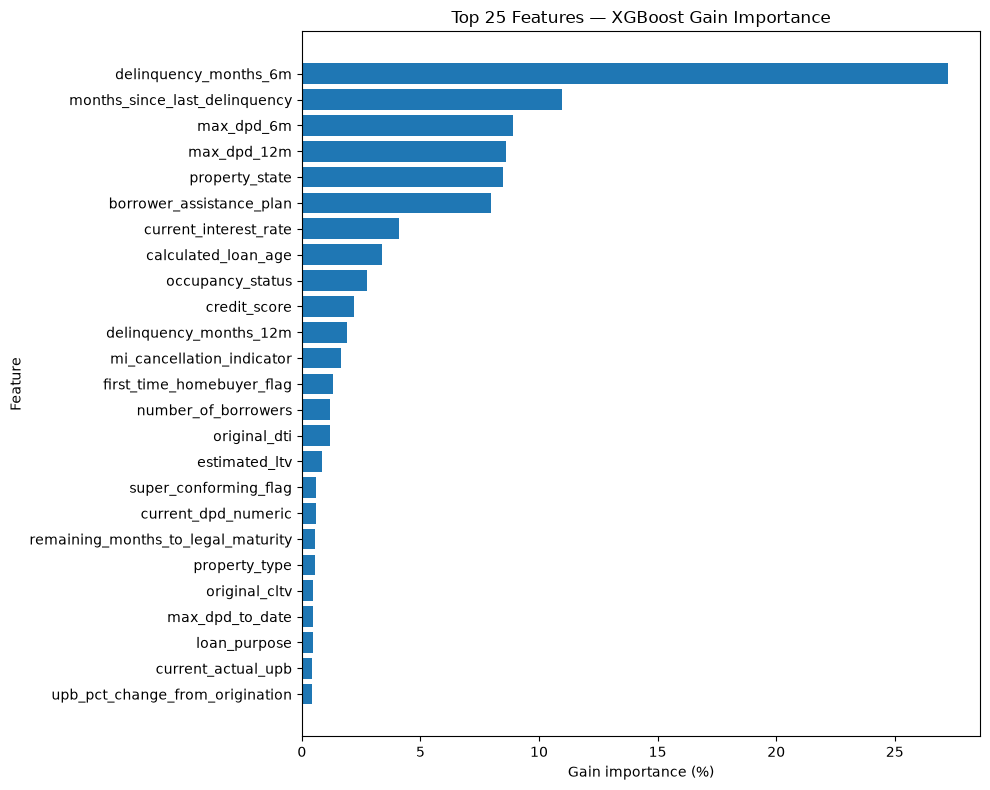

In [20]:
top_n = 25

top_features = aggregated_importance.head(top_n).sort_values("gain")

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["original_feature"],
    top_features["gain_pct"],
)

plt.xlabel("Gain importance (%)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features — XGBoost Gain Importance")

plt.tight_layout()
plt.show()

In [21]:
numerical_features = set(features_config["numerical_features"])

categorical_features = set(features_config["categorical_features"])

engineered_features = set(features_config["engineered_features"])


def feature_group(feature):

    if feature in numerical_features:
        return "Numerical"

    if feature in categorical_features:
        return "Categorical"

    if feature in engineered_features:
        return "Engineered"

    return "Other"


aggregated_importance["feature_group"] = aggregated_importance[
    "original_feature"
].apply(feature_group)

group_importance = aggregated_importance.groupby("feature_group", as_index=False)[
    "gain"
].sum()

group_importance["gain_pct"] = (
    group_importance["gain"] / group_importance["gain"].sum() * 100
)

group_importance.sort_values(
    "gain",
    ascending=False,
)

,feature_group,gain,gain_pct
2,Numerical,15863.462898,75.166745
0,Categorical,5189.630887,24.590322
1,Engineered,51.269424,0.242933


In [22]:
origination_features = {
    "number_of_borrowers",
    "mi_percentage",
    "original_upb",
    "credit_score",
    "original_dti",
    "original_ltv",
    "original_cltv",
    "original_interest_rate",
    "original_loan_term",
    "first_time_homebuyer_flag",
    "property_type",
    "occupancy_status",
    "loan_purpose",
    "channel",
    "super_conforming_flag",
    "harp_indicator",
    "property_state",
    "original_dti_missing",
}

behavioral_features = set(all_model_features) - origination_features


def modelling_feature_group(feature):

    if feature in origination_features:
        return "Origination"

    if feature in behavioral_features:
        return "Behavioral"

    return "Other"


aggregated_importance["modelling_group"] = aggregated_importance[
    "original_feature"
].apply(modelling_feature_group)

group_importance = aggregated_importance.groupby("modelling_group", as_index=False)[
    "gain"
].sum()

group_importance["gain_pct"] = (
    group_importance["gain"] / group_importance["gain"].sum() * 100
)

group_importance.sort_values(
    "gain",
    ascending=False,
)

,modelling_group,gain,gain_pct
0,Behavioral,16755.801537,79.394964
1,Origination,4348.561673,20.605036


In [23]:
behavioral_importance = aggregated_importance[
    aggregated_importance["modelling_group"] == "Behavioral"
].sort_values(
    "gain",
    ascending=False,
)

behavioral_importance[
    [
        "original_feature",
        "gain_pct",
        "weight",
        "cover",
    ]
].head(30)

,original_feature,gain_pct,weight,cover
10,delinquency_months_6m,27.231463,63.0,12921.736328
24,months_since_last_delinquency,10.964770,66.0,8844.193359
20,max_dpd_6m,8.898046,116.0,7554.993652
19,max_dpd_12m,8.613038,80.0,21096.197266
0,borrower_assistance_plan,7.983847,36.0,41080.535126
7,current_interest_rate,4.082488,526.0,11475.839844
1,calculated_loan_age,3.393536,138.0,16014.349609
9,delinquency_months_12m,1.899435,32.0,10145.172852
22,mi_cancellation_indicator,1.646167,16.0,3212.196022
14,estimated_ltv,0.854266,168.0,13125.576172


In [24]:
origination_importance = aggregated_importance[
    aggregated_importance["modelling_group"] == "Origination"
].sort_values(
    "gain",
    ascending=False,
)

origination_importance[
    [
        "original_feature",
        "gain_pct",
        "weight",
        "cover",
    ]
].head(30)

,original_feature,gain_pct,weight,cover
32,property_state,8.490356,602.0,830723.983498
26,occupancy_status,2.746574,64.0,52466.587570
3,credit_score,2.199372,416.0,13589.600586
16,first_time_homebuyer_flag,1.333237,45.0,20759.932617
25,number_of_borrowers,1.186727,181.0,18770.277344
28,original_dti,1.182062,248.0,18008.462891
35,super_conforming_flag,0.606304,13.0,34301.830078
33,property_type,0.536692,59.0,19522.037537
27,original_cltv,0.484871,210.0,9977.750977
18,loan_purpose,0.452375,95.0,19894.079346


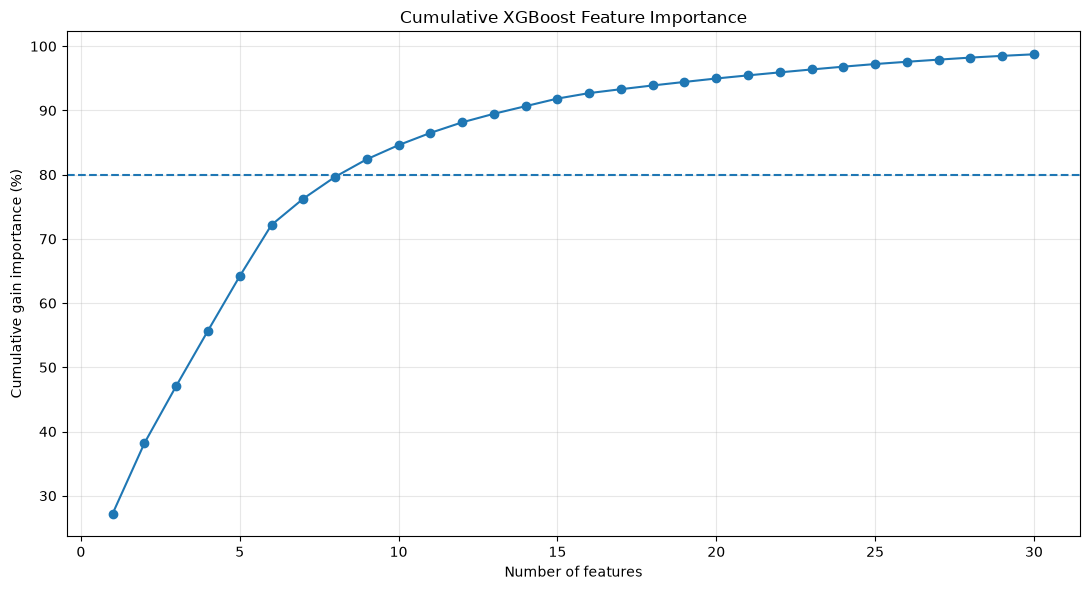

In [25]:
top_features = aggregated_importance.head(30)

plt.figure(figsize=(11, 6))

plt.plot(
    range(1, len(top_features) + 1),
    top_features["cumulative_gain_pct"],
    marker="o",
)

plt.axhline(
    80,
    linestyle="--",
)

plt.xlabel("Number of features")
plt.ylabel("Cumulative gain importance (%)")
plt.title("Cumulative XGBoost Feature Importance")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
importance_table = (
    aggregated_importance[
        [
            "original_feature",
            "feature_group",
            "modelling_group",
            "gain",
            "gain_pct",
            "cumulative_gain_pct",
            "weight",
            "cover",
        ]
    ]
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

importance_table

,original_feature,feature_group,modelling_group,gain,gain_pct,cumulative_gain_pct,weight,cover
0,delinquency_months_6m,Numerical,Behavioral,5747.026855,27.231463,27.231463,63.0,12921.736328
1,months_since_last_delinquency,Numerical,Behavioral,2314.044922,10.964770,38.196233,66.0,8844.193359
2,max_dpd_6m,Numerical,Behavioral,1877.875977,8.898046,47.094279,116.0,7554.993652
3,max_dpd_12m,Numerical,Behavioral,1817.726807,8.613038,55.707317,80.0,21096.197266
4,property_state,Categorical,Origination,1791.835672,8.490356,64.197674,602.0,830723.983498
5,borrower_assistance_plan,Categorical,Behavioral,1684.940039,7.983847,72.181521,36.0,41080.535126
6,current_interest_rate,Numerical,Behavioral,861.583130,4.082488,76.264009,526.0,11475.839844
7,calculated_loan_age,Numerical,Behavioral,716.184143,3.393536,79.657545,138.0,16014.349609
8,occupancy_status,Categorical,Origination,579.646922,2.746574,82.404118,64.0,52466.587570
9,credit_score,Numerical,Origination,464.163544,2.199372,84.603491,416.0,13589.600586
